In [1]:
from IPython.display import Image
import xarray as xr
import numpy as np
import math
import cartopy.crs as ccrs # for geographic plotting
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from global_land_mask import globe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from matplotlib.colors import to_hex
import glob
import os
import pandas as pd
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
# Dictionnaire des modèles et de leurs chemins
cmip6_models = {
    "EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/pr/gr/v20200312/",
    "EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/pr/gr/v20200213/",
    "ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/pr/gn/latest/",
    "SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/pr/gn/v20190910/",
    "GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/pr/gr1/v20180701/",
    "GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/pr/gr1/v20180701/",
    "NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/pr/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/pr/gn/v20190222/",
    "UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/pr/gn/v20200828/",
    "HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/pr/gn/v20190628/",
}

dict_mslp = {    
    "EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/psl/gr/v20200312/",
    "EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/psl/gr/v20200213/",
    "ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/psl/gn/latest/",
    "SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/psl/gn/v20190910/",
    "GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/psl/gr1/v20180701/",
    "GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/psl/gr1/v20180701/",
    "NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/psl/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/psl/gn/v20190222/",
    "UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/psl/gn/v20200828/",
    "HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/psl/gn/v20190628/",
}

# Dictionnaires pour stocker les résultats finaux
all_cmip_composites = {}
all_cmip_triples = {}
all_cmip_stds = {}
all_results = {} 

In [3]:
# Charger ton catalogue créé précédemment
catalog = pd.read_csv('/g/data/m35/qr1706/PhD-1_CMIP_analysis/csv_npy/triple_lanina_catalog_sp.csv')

# Liste ordonnée de tes modèles (pour le plot 3x4, on en choisit 10 + 2 vides ou 12)
model_list = list(cmip6_models.keys()) 
years_labels = ["yr1", "yr2", "yr3"]
months_ndjfm = [12, 1, 2] # Utilisation des numéros pour groupby

In [4]:
all_results = {} # Initialize the main dictionary

for name in model_list:
    print(f"Processing {name}...")
    path = cmip6_models[name]
    
    try:
        # 1. Open without decoding to handle metadata
        ds_raw = xr.open_mfdataset(path + "*.nc", chunks={'time': 120}, 
                                   combine='by_coords', decode_times=False)
        
        # --- IPSL SPECIFIC FIX ---
        if name == 'IPSL-CM6A-LR':
            # Force the units to align the 1200-year offset found earlier
            ds_raw.time.attrs['units'] = "days since 1850-01-01 00:00:00"
            # IPSL specifically needs this calendar to match the unit shift
            ds_raw.time.attrs['calendar'] = 'proleptic_gregorian'
        
        # --- GENERAL CALENDAR SAFETY ---
        # Only set a default if the attribute is missing to avoid conflicts
        if 'calendar' not in ds_raw.time.attrs:
            ds_raw.time.attrs['calendar'] = 'standard'
            
        # Decode the dataset with the corrected metadata
        ds = xr.decode_cf(ds_raw, use_cftime=True)
        pr = ds.pr * 86400 # Convert to mm/day

        # 2. Climatology NDJFM
        clim_ndjfm = pr.groupby("time.month").mean(dim="time").sel(month=[12, 1, 2]).mean(dim='month').compute()

        # 3. Get dates from catalog
        triple_starts = catalog[catalog['model'] == name]['triple_start_year'].values
        n_events_catalog = len(triple_starts)
        
        if n_events_catalog == 0:
            print(f"  -> Skipped: No events found in catalog for {name}")
            continue

        all_results[name] = {}

        # 4. Loop through the 3 years of the Triple La Niña
        for i, y_lab in enumerate(["yr1", "yr2", "yr3"]):
            event_composites = []
            for start_year in triple_starts:
                target_year = int(start_year) + i
                
                try:
                    # Robust selection using the model's own calendar
                    # We use the calendar directly from the decoded dataset
                    model_cal = ds.time.encoding.get('calendar', ds.time.attrs.get('calendar', 'standard'))
                    
                    d1 = xr.cftime_range(start=f"{target_year:04d}-12-01", periods=1, calendar=model_cal)[0]
                    d2 = xr.cftime_range(start=f"{(target_year+1):04d}-02-28", periods=1, calendar=model_cal)[0]
                    
                    # Select the season
                    season = pr.sel(time=slice(d1, d2)).mean(dim='time').compute()
                    
                    if season.notnull().any():
                        event_composites.append(season)
                except:
                    continue # Skip if specific year fails
            
            if event_composites:
                # Store the raw stacked data for the 'Pro Method'
                all_results[name][y_lab] = {
                    'stacked_events': xr.concat(event_composites, dim='event'), 
                    'clim_ref': clim_ndjfm, 
                    'n': len(event_composites)
                }
        
        # Print final count for Year 3 to confirm success
        final_n = len(event_composites) if event_composites else 0
        print(f"✅ {name} finished (n={final_n})")
        ds.close()

    except Exception as e:
        print(f"❌ Error {name}: {e}")

Processing EC-Earth3...
✅ EC-Earth3 finished (n=8)
Processing EC-Earth3-Veg-LR...
✅ EC-Earth3-Veg-LR finished (n=7)
Processing ACCESS-ESM1-5...
✅ ACCESS-ESM1-5 finished (n=10)
Processing SAMO-UNICON...
✅ SAMO-UNICON finished (n=18)
Processing GFDL-ESM4...
✅ GFDL-ESM4 finished (n=13)
Processing GFDL-CM4...
✅ GFDL-CM4 finished (n=11)
Processing NorESM2-MM...
✅ NorESM2-MM finished (n=17)
Processing MRI-ESM2-0...
✅ MRI-ESM2-0 finished (n=6)
Processing UKESM1-0-LL...
✅ UKESM1-0-LL finished (n=36)
Processing HadGEM3-GC31-LL...
✅ HadGEM3-GC31-LL finished (n=8)


In [5]:
# --- STEP 1-BIS: PROCESSING FOR SEPTEMBER-OCTOBER (SO) ---
all_results_so = {} # Initialize a separate dictionary for SO data

for name in model_list:
    print(f"Processing {name} (SON season)...")
    path = cmip6_models[name]
    
    try:
        # 1. Load without decoding to handle problematic metadata
        ds_raw = xr.open_mfdataset(path + "*.nc", chunks={'time': 120}, 
                                   combine='by_coords', decode_times=False)
        
        # --- IPSL SPECIFIC FIX (The 1200-year offset) ---
        if name == 'IPSL-CM6A-LR':
            ds_raw.time.attrs['units'] = "days since 1850-01-01 00:00:00"
            ds_raw.time.attrs['calendar'] = 'proleptic_gregorian'
        
        # --- GENERAL CALENDAR SAFETY ---
        # Respect the original calendar if it exists, otherwise default to standard
        if 'calendar' not in ds_raw.time.attrs:
            ds_raw.time.attrs['calendar'] = 'standard'
            
        # Decode using the corrected metadata
        ds = xr.decode_cf(ds_raw, use_cftime=True)
        pr = ds.pr * 86400 # Convert to mm/day

        # 2. Climatology SO (Sept-Oct)
        clim_so = pr.groupby("time.month").mean(dim="time").sel(month=[9, 10, 11]).mean(dim='month').compute()

        # 3. Get dates from catalog
        triple_starts = catalog[catalog['model'] == name]['triple_start_year'].values
        n_events_catalog = len(triple_starts)
        
        if n_events_catalog == 0:
            print(f"  -> Skipped: No events for {name}")
            continue

        all_results_so[name] = {}

        # 4. Loop through the 3 years
        for i, y_lab in enumerate(["yr1", "yr2", "yr3"]):
            event_composites = []
            for start_year in triple_starts:
                target_year = int(start_year) + i
                
                try:
                    # Robust selection using the model's native calendar type
                    model_cal = ds.time.encoding.get('calendar', ds.time.attrs.get('calendar', 'standard'))
                    
                    # Define SO dates (Same calendar year)
                    d1 = xr.cftime_range(start=f"{target_year:04d}-09-01", periods=1, calendar=model_cal)[0]
                    d2 = xr.cftime_range(start=f"{target_year:04d}-11-30", periods=1, calendar=model_cal)[0]
                    
                    # Compute seasonal mean
                    season = pr.sel(time=slice(d1, d2)).mean(dim='time').compute()
                    
                    if season.notnull().any():
                        event_composites.append(season)
                except:
                    continue # Skip if specific year fails
            
            if event_composites:
                all_results_so[name][y_lab] = {
                    'stacked_events': xr.concat(event_composites, dim='event'), 
                    'clim_ref': clim_so, 
                    'n': len(event_composites)
                }
        
        # Confirmation message with the count from the last year processed
        final_n = len(event_composites) if event_composites else 0
        print(f"✅ {name} SON finished (n={final_n})")
        ds.close()

    except Exception as e:
        print(f"❌ Error {name}: {e}")

Processing EC-Earth3 (SON season)...
✅ EC-Earth3 SON finished (n=8)
Processing EC-Earth3-Veg-LR (SON season)...
✅ EC-Earth3-Veg-LR SON finished (n=7)
Processing ACCESS-ESM1-5 (SON season)...
✅ ACCESS-ESM1-5 SON finished (n=10)
Processing SAMO-UNICON (SON season)...
✅ SAMO-UNICON SON finished (n=18)
Processing GFDL-ESM4 (SON season)...
✅ GFDL-ESM4 SON finished (n=13)
Processing GFDL-CM4 (SON season)...
✅ GFDL-CM4 SON finished (n=11)
Processing NorESM2-MM (SON season)...
✅ NorESM2-MM SON finished (n=17)
Processing MRI-ESM2-0 (SON season)...
✅ MRI-ESM2-0 SON finished (n=6)
Processing UKESM1-0-LL (SON season)...
✅ UKESM1-0-LL SON finished (n=36)
Processing HadGEM3-GC31-LL (SON season)...
✅ HadGEM3-GC31-LL SON finished (n=8)


In [6]:
# --- FUNCTION TO CALCULATE AGREEMENT AND ANOMALIES ---
# This function automates the post-processing for any season provided
def process_agreement(input_dict, threshold=0.80):
    output_dict = {} # Initialize the results dictionary
    
    for name in input_dict.keys():
        output_dict[name] = {} # Create sub-dictionary for the model
        for y_lab in ["yr1", "yr2", "yr3"]:
            try:
                data = input_dict[name][y_lab]
                
                # 1. Calculate the mean anomaly in %
                anom_pc = (data['stacked_events'].mean(dim='event') / data['clim_ref'] - 1) * 100
                
                # 2. Calculate sign agreement mask
                anom_indiv = data['stacked_events'] - data['clim_ref']
                n = data['n']
                needed = np.ceil(n * threshold)
                
                agreement = (anom_indiv > 0).sum(dim='event') >= needed
                disagreement = (anom_indiv < 0).sum(dim='event') >= needed
                
                # 3. Combine agreement and 10% magnitude threshold
                mask_final = (agreement | disagreement) & (np.abs(anom_pc) > 10)
                
                # 4. Dynamic coordinate detection (for IPSL and others)
                curr_lat = [c for c in mask_final.coords if 'lat' in c.lower()][0]
                curr_lon = [c for c in mask_final.coords if 'lon' in c.lower()][0]
                
                # 5. Coarsen mask for hatching
                mask_res = mask_final.astype(float).coarsen({curr_lat: 2, curr_lon: 2}, boundary='trim').mean() > 0.5
                
                output_dict[name][y_lab] = {
                    'anom': anom_pc, 
                    'mask': mask_res, 
                    'n': n
                }
            except Exception as e:
                # Silent skip if year is missing
                continue
                
    return output_dict # Return the final dictionary ready for plotting

In [62]:
def process_agreement(input_dict, threshold=0.80):
    output_dict = {}
    
    # --- GRILLE CIBLE COMMUNE (ex: 2x2 degrés pour un rendu propre) ---
    target_lat = np.arange(-55, 12, 2)
    target_lon = np.arange(80, 182, 2)
    
    for name in input_dict.keys():
        output_dict[name] = {}
        for y_lab in ["yr1", "yr2", "yr3"]:
            try:
                data = input_dict[name][y_lab]
                
                # 1. Calcul de l'anomalie % (sur grille native)
                anom_pc = (data['stacked_events'].mean(dim='event') / data['clim_ref'] - 1) * 100
                
                # 2. Calcul du masque d'accord (sur grille native)
                anom_indiv = data['stacked_events'] - data['clim_ref']
                n = data['n']
                needed = np.ceil(n * threshold)
                
                agreement = (anom_indiv > 0).sum(dim='event') >= needed
                disagreement = (anom_indiv < 0).sum(dim='event') >= needed
                mask_native = (agreement | disagreement) & (np.abs(anom_pc) > 10)
                
                # --- 3. REGRIDDING DU MASQUE SUR LA GRILLE COMMUNE ---
                # On convertit le booléen en float (0.0 ou 1.0) pour interpoler
                # On utilise 'nearest' pour garder des valeurs 0 ou 1 propres
                curr_lat = [c for c in mask_native.coords if 'lat' in c.lower()][0]
                curr_lon = [c for c in mask_native.coords if 'lon' in c.lower()][0]
                
                mask_interp = mask_native.astype(float).interp(
                    {curr_lat: target_lat, curr_lon: target_lon}, 
                    method='nearest'
                )
                
                output_dict[name][y_lab] = {
                    'anom': anom_pc,        # Garde l'anomalie haute résolution pour les couleurs
                    'mask_pts': mask_interp, # Masque uniformisé pour les points
                    'n': n
                }
            except Exception as e:
                continue
                
    return output_dict

### For DJF

In [76]:
# Process NDJFM data using our new function
processed_plots = process_agreement(all_results, threshold=0.80) # Use the NDJFM raw data

# 2. Set a manual flag
current_season = "DJF"

# Now you can run your Plotting Cell
print(f"DJF processing complete. Models: {list(processed_plots.keys())}")

DJF processing complete. Models: ['EC-Earth3', 'EC-Earth3-Veg-LR', 'ACCESS-ESM1-5', 'SAMO-UNICON', 'GFDL-ESM4', 'GFDL-CM4', 'NorESM2-MM', 'MRI-ESM2-0', 'UKESM1-0-LL', 'HadGEM3-GC31-LL']


### For SON

In [77]:
# Process SO data using the same function
processed_plots_so = process_agreement(all_results_so, threshold=0.80) # Use the SO raw data

# 2. Set a manual flag
current_season = "SON"

# Now you can run your Plotting Cell (same cell as before, but the data has changed!)
print(f"SON processing complete. Models: {list(processed_plots.keys())}")

import seaborn as sns
from matplotlib.colors import ListedColormap

# --- PREPARE SO CUSTOM PALETTE ---
# Sept-Oct (SO) needs a wider scale: -75% to +250% (14 levels total)
# 3 levels for negative (Brown), 1 neutral/zero, 10 levels for positive (Green)
color_ex = sns.color_palette("BrBG", n_colors=22)
BG = color_ex[11:22] # Positive anomalies (Green)
color10 = sns.color_palette("BrBG", n_colors=8)
Br = color10[0:4] # Negative anomalies (Brown)
Br.extend(BG) # Merge both lists

# Create a Matplotlib colormap from the Seaborn list
custom_SO_cmap = ListedColormap(Br)

SON processing complete. Models: ['EC-Earth3', 'EC-Earth3-Veg-LR', 'ACCESS-ESM1-5', 'SAMO-UNICON', 'GFDL-ESM4', 'GFDL-CM4', 'NorESM2-MM', 'MRI-ESM2-0', 'UKESM1-0-LL', 'HadGEM3-GC31-LL']


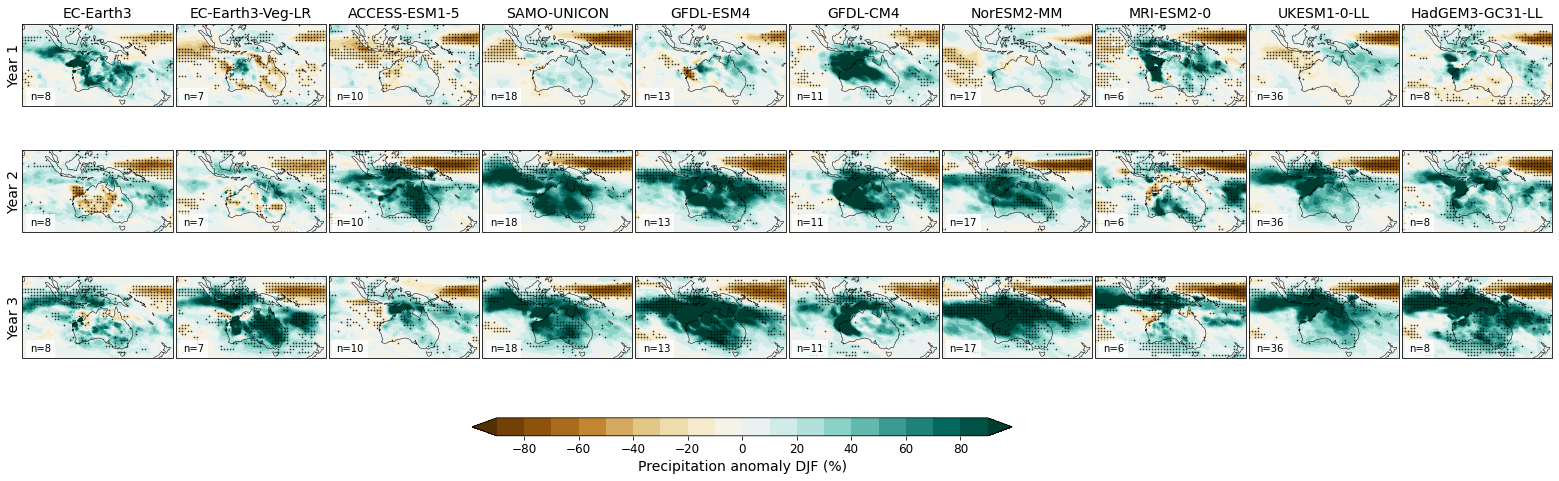

In [27]:
# --- STEP 3: PLOTTING ---
import matplotlib.colors as mcolors # Required for the SO custom cmap

# 1. Identify active models
active_models = [m for m in model_list if m in processed_plots and processed_plots[m]]

if not active_models:
    print("No active models found.")
else:
    # 2. SELECTION OF SCALE AND COLORMAP
    # The condition only handles the SETTINGS, the drawing code follows after
    if 'current_season' in locals() and current_season == "SO":
        # --- SCALE & PALETTE FOR SEPT-OCT (SO) ---
        lvl = np.arange(-75, 275, 25) 
        color_ex = sns.color_palette("BrBG", n_colors=22)
        BG = color_ex[11:22]
        color10 = sns.color_palette("BrBG", n_colors=8)
        Br = color10[0:4]
        Br.extend(BG)
        current_cmap = mcolors.ListedColormap(Br)
        cbar_label = 'Precipitation anomaly SON (%)'
        save_name = 'SON_Composite_Precip_spx3_Models.png'
    else:
        # --- SCALE & PALETTE FOR NDJFM (Default) ---
        lvl = np.arange(-90, 100, 10)
        current_cmap = 'BrBG'
        cbar_label = 'Precipitation anomaly DJF (%)'
        save_name = 'DJF_Composite_Precip_spx3_Models.png'

    # 3. Initialize Figure (Now OUTSIDE the if/else logic)
    n_cols = len(active_models)
    fig, axes = plt.subplots(nrows=3, ncols=n_cols, figsize=(2.5 * n_cols, 10), 
                             subplot_kw={'projection': ccrs.PlateCarree()})
    
    fig.subplots_adjust(wspace=0.02, hspace=-0.5)

    # 4. Drawing Loop
    for col, m_name in enumerate(active_models):
        for row, y_lab in enumerate(["yr1", "yr2", "yr3"]):
            ax = axes[row, col]
            data = processed_plots[m_name][y_lab]
            
            # --- 1. PLOT ANOMALY (Contourf principal) ---
            im = data['anom'].plot.contourf(ax=ax, levels=lvl, cmap=current_cmap, 
                                            add_colorbar=False, extend='both', 
                                            transform=ccrs.PlateCarree())
            
# --- 2. PLOT AGREEMENT MASK (Uniformisé) ---
            m_pts = data['mask_pts']
            # On récupère les indices où le masque est à 1
            lat_idx, lon_idx = np.where(m_pts.values > 0.5)
            
            if len(lat_idx) > 0:
                ax.scatter(m_pts.lon.values[lon_idx], m_pts.lat.values[lat_idx], 
                           marker='.', s=2, color='black', 
                           alpha=0.7, transform=ccrs.PlateCarree())
            # --- 3. COSMETICS ---
            ax.coastlines(linewidth=0.5)
            # On définit l'étendue APRÈS le scatter pour être sûr du zoom
            ax.set_extent([80, 180, -45, 10], crs=ccrs.PlateCarree())            
            if row == 0:
                ax.set_title(m_name, fontsize=14, fontweight='normal')
            
            if col == 0:
                row_titles = ["Year 1", "Year 2", "Year 3"]
                ax.text(-0.1, 0.5, row_titles[row], transform=ax.transAxes, 
                        fontsize=14, va='center', rotation=90)

            ax.text(0.05, 0.08, f"n={data['n']}", transform=ax.transAxes, 
                    fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # 5. Add Horizontal Colorbar
    cbar_ax = fig.add_axes([0.35, 0.23, 0.3, 0.025])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(cbar_label, fontsize=14, fontweight='normal')
    cbar.ax.tick_params(labelsize=12)

    # 6. Final Layout and Save
    plt.subplots_adjust(top=0.92, bottom=0.22, left=0.1, right=0.95)
    
    # Use the dynamic save_name based on the season
    plt.savefig(f'/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/pr/{save_name}', 
                dpi=300, bbox_inches='tight', pad_inches=0.2, facecolor='white', edgecolor='none')
    
    plt.show()